In [2]:
import matplotlib.pyplot as plt  # 绘图（用于可视化决策树）
from sklearn.datasets import load_breast_cancer  # 加载乳腺癌分类数据集
from sklearn.model_selection import train_test_split  # 划分训练集/测试集
from sklearn.tree import DecisionTreeClassifier,plot_tree  # 决策树模型+可视化
from sklearn.model_selection import cross_val_score  # 交叉验证（选最优剪枝参数）

In [3]:
X,y = load_breast_cancer(return_X_y=True)

X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=2,stratify=y)


In [5]:
# 预剪枝参数设置
model = DecisionTreeClassifier(
    max_depth=3,               # 树的最大深度（超过则停止分裂）
    min_samples_split=10,      # 节点最小样本数 <10 则不再分裂
    min_samples_leaf=5,        # 叶节点最小样本数 <5 则合并
    max_leaf_nodes=20,         # 最大叶节点数量
    random_state=42
)
model.fit(X_train,y_train)
print("叶节点数量:", model.get_n_leaves())  # 输出实际生成的叶节点数


叶节点数量: 7


In [6]:
#后剪枝策略
#获取所有可能的剪枝参数 ccp_alphas（每个值对应一种剪枝强度）
prun_before=DecisionTreeClassifier(random_state=42)
prun_before.fit(X_train,y_train)
path = prun_before.cost_complexity_pruning_path(X_train,y_train)
print(path)
ccp_alphas = path.ccp_alphas  # 剪枝系数（值越大，剪枝越激进）
ccp_impur=path.impurities#树的不纯度
#print(ccp_alphas)
#print(ccp_impur)


{'ccp_alphas': array([0.        , 0.00233721, 0.00307944, 0.00312989, 0.00312989,
       0.00375587, 0.00456248, 0.00508607, 0.00508607, 0.00804829,
       0.0092494 , 0.01018672, 0.01346662, 0.04971454, 0.32928553]), 'impurities': array([0.        , 0.00467442, 0.01391274, 0.01704264, 0.02017253,
       0.02392839, 0.02849087, 0.03357695, 0.03866302, 0.04671131,
       0.06521011, 0.07539684, 0.08886345, 0.13857799, 0.46786352])}


In [7]:
#通过交叉验证选择最佳剪枝强度
scores = []
for alpha in ccp_alphas:
    pruned_model = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    score = cross_val_score(pruned_model,X_train,y_train, cv=5).mean()
    scores.append(score)
best_alpha = ccp_alphas[scores.index(max(scores))]
print(scores)
print(best_alpha)


[np.float64(0.8966073871409028), np.float64(0.8966073871409028), np.float64(0.9013406292749657), np.float64(0.9013406292749657), np.float64(0.9013406292749657), np.float64(0.9013406292749657), np.float64(0.9013406292749657), np.float64(0.8989876880984952), np.float64(0.8989876880984952), np.float64(0.9295485636114911), np.float64(0.9295485636114911), np.float64(0.9319015047879617), np.float64(0.9342544459644323), np.float64(0.8966347469220246), np.float64(0.7837756497948016)]
0.013466617753206851


In [8]:
#用最优 alpha 重新训练模
print(prun_before.score(X_test,y_test))#预剪枝产生的模型在测试集上的召回率
pruned_model = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
pruned_model.fit(X_train,y_train)
print(pruned_model.score(X_test,y_test))#后剪枝产生的模型在测试集上的召回率


0.9300699300699301
0.9440559440559441


剪枝前叶节点数: 19
剪枝后叶节点数: 3


[Text(0.6, 0.8333333333333334, 'x[20] <= 16.795\ngini = 0.468\nsamples = 426\nvalue = [159, 267]'),
 Text(0.4, 0.5, 'x[27] <= 0.16\ngini = 0.155\nsamples = 283\nvalue = [24, 259]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.072\nsamples = 267\nvalue = [10, 257]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.219\nsamples = 16\nvalue = [14, 2]'),
 Text(0.8, 0.5, 'gini = 0.106\nsamples = 143\nvalue = [135, 8]'),
 Text(0.7, 0.6666666666666667, '  False')]

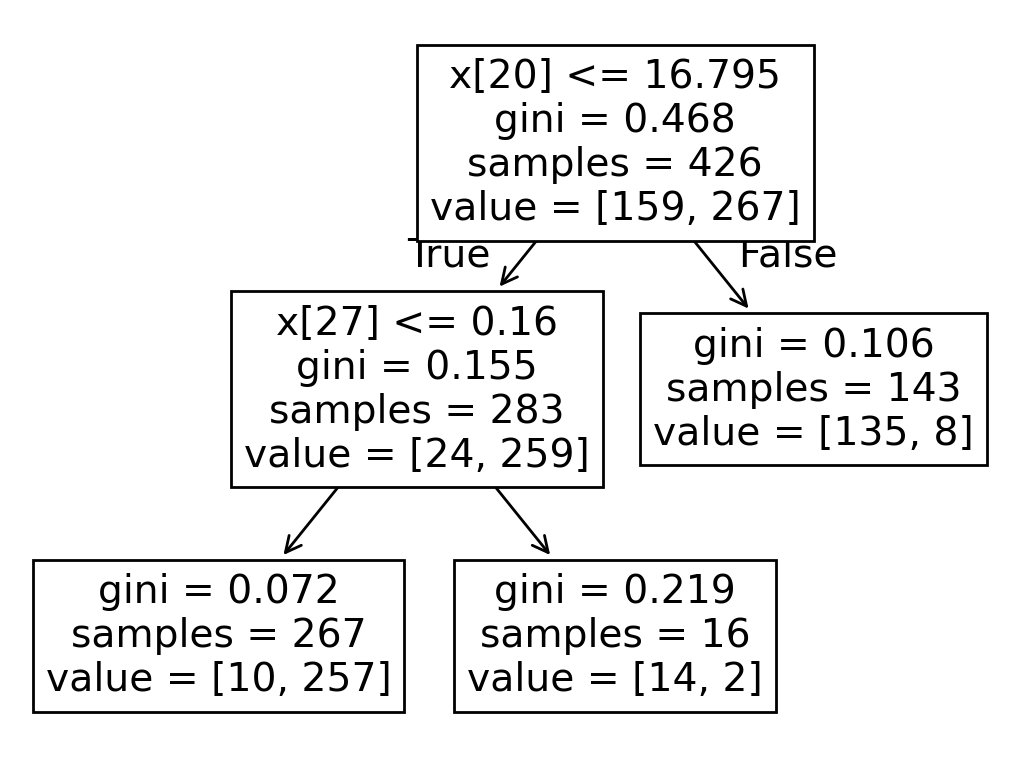

In [9]:
print("剪枝前叶节点数:", prun_before.get_n_leaves())  # 完全生长的树
print("剪枝后叶节点数:", pruned_model.get_n_leaves())
plt.rcParams['font.size'] = 12 #图片像素
plt.rcParams['figure.dpi'] = 200 #分辨率
plot_tree(pruned_model)
